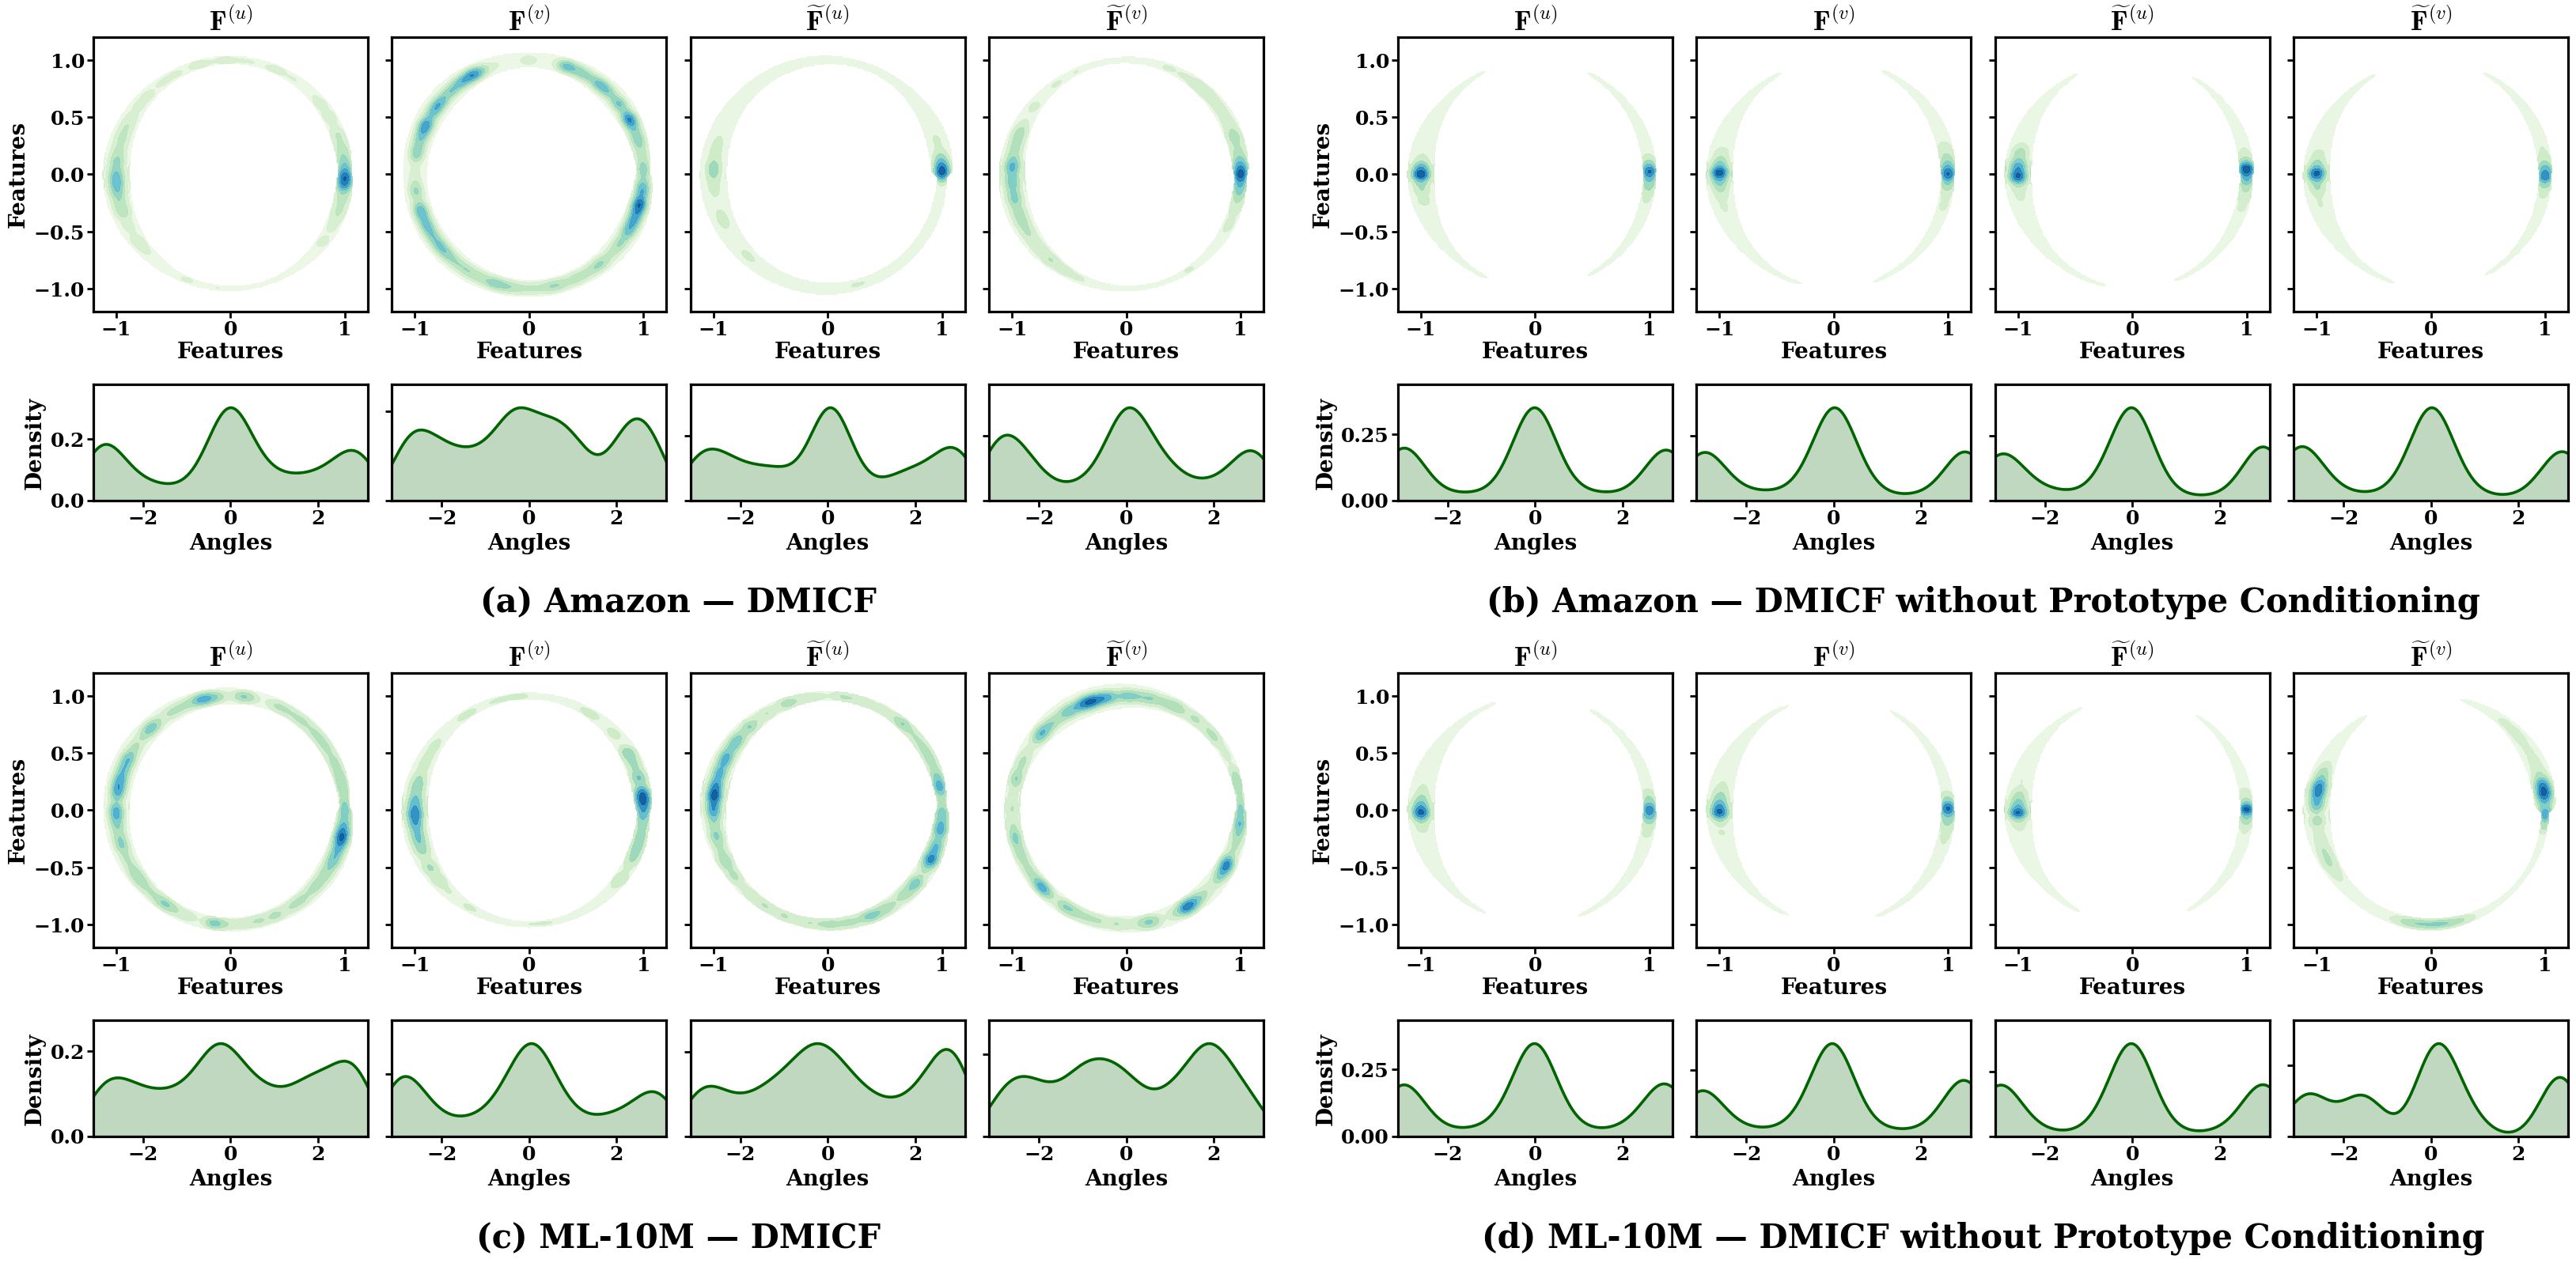

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import matplotlib as mpl

# ======================================================
# 0. 全局风格
# ======================================================
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.linewidth": 2.3,
})

# ======================================================
# 1. 配置
# ======================================================
datasets = ["Amazon", "ML10M"]
methods = ["DMICF", "DMICF_no_intent"]

cache_dirs = {
    ("Amazon", "DMICF"): "amazon-tsne_cache",
    ("ML10M", "DMICF"): "ml10m-tsne_cache",
    ("Amazon", "DMICF_no_intent"): "no-amazon-tsne_cache",
    ("ML10M", "DMICF_no_intent"): "no-ml10m-tsne_cache",
}

emb_order = ["u_sim", "i_sim", "u_agg", "i_agg"]

titles_inner = [
    r"$\mathbf{F}^{(u)}$",
    r"$\mathbf{F}^{(v)}$",
    r"$\widetilde{\mathbf{F}}^{(u)}$",
    r"$\widetilde{\mathbf{F}}^{(v)}$",
]

figure_titles = [
    "(a) Amazon — DMICF",
    "(b) Amazon — DMICF without Prototype Conditioning",
    "(c) ML-10M — DMICF",
    "(d) ML-10M — DMICF without Prototype Conditioning",
]

# ======================================================
# 2. KDE 工具
# ======================================================
def ring_kde(
    z_unit,
    grid=260,
    r_center=1.0,
    max_thickness=0.12,     # 圆环最大厚度
    angle_bw=None,          # 和下方角度图一致的默认带宽
    abs_theta_thresh=0.01,  # 低密阈值（变细）
    theta_break_thresh=0.05,  # 极低密阈值（完全断裂）
    abs_2d_thresh=1e-5,     # 低密阈值（变细）
    d_break_thresh=5e-6,   # 极低密阈值（完全断裂）
    kde_2d_bw=0.06,         # 2D KDE带宽
    levels=6,               # 等高线层数
    smooth_sigma=1.2,       # 高斯平滑核大小
    soft_factor=0.8         # 软阈值过渡系数
):
    from scipy.ndimage import gaussian_filter
    # ---------- 1. 角度KDE（分层阈值：断裂+平滑过渡） ----------
    angles = np.arctan2(z_unit[:, 1], z_unit[:, 0])
    angles = np.where(angles < 0, angles + 2 * np.pi, angles)

    angle_grid = np.linspace(0, 2 * np.pi, 720)
    kde_angle = gaussian_kde(angles, bw_method=angle_bw)
    dens_theta = kde_angle(angle_grid)

    # 核心1：分层处理（极低密=断裂，低密=软过渡，高密=保留）
    dens_theta_processed = dens_theta.copy()
    # ① 极低密区域（<断裂阈值）：直接置0（完全断裂）
    break_mask = dens_theta < theta_break_thresh
    dens_theta_processed[break_mask] = 0.0
    # ② 低密区域（断裂阈值~过滤阈值）：软过渡（渐变变细）
    soft_mask = (dens_theta >= theta_break_thresh) & (dens_theta < abs_theta_thresh)
    dens_theta_processed[soft_mask] = dens_theta_processed[soft_mask] * soft_factor / abs_theta_thresh
    # ③ 高密区域：保留原始值
    # 高斯平滑（仅让过渡边缘平滑，断裂区域仍为0）
    dens_theta_smooth = gaussian_filter(dens_theta_processed, sigma=smooth_sigma)

    # ---------- 2. 2D网格 + 极坐标转换 ----------
    x = np.linspace(-1.3, 1.3, grid)
    y = np.linspace(-1.3, 1.3, grid)
    xx, yy = np.meshgrid(x, y)

    rr = np.sqrt(xx**2 + yy**2)
    tt = np.arctan2(yy, xx)
    tt = np.where(tt < 0, tt + 2 * np.pi, tt)

    # ---------- 3. 2D核密度（分层阈值：断裂+平滑） ----------
    kde_2d = gaussian_kde(z_unit.T, bw_method=kde_2d_bw)
    grid_points = np.vstack([xx.ravel(), yy.ravel()])
    dens_2d = kde_2d(grid_points).reshape(xx.shape)
    dens_2d_smooth = gaussian_filter(dens_2d, sigma=smooth_sigma)

    # ---------- 4. 圆环厚度（取消最小厚度限制，允许厚度到0） ----------
    dens_map = np.interp(tt, angle_grid, dens_theta_smooth)
    dens_map_smooth = gaussian_filter(dens_map, sigma=smooth_sigma)
    
    # 核心2：取消最小厚度clip，允许厚度降到0（断裂）
    thickness = max_thickness * (dens_map_smooth / (dens_map_smooth.max() if dens_map_smooth.max() > 1e-6 else 1))
    # 仅限制最大厚度（避免过宽），最小厚度允许为0
    thickness = np.clip(thickness, 0.0, max_thickness)  
    thickness_smooth = gaussian_filter(thickness, sigma=smooth_sigma)

    r_inner = r_center - thickness_smooth
    r_outer = r_center + thickness_smooth

    # ---------- 5. 生成密度图（分层过滤：断裂+平滑） ----------
    dens = np.full_like(rr, np.nan)
    mask = (rr >= r_inner) & (rr <= r_outer)
    dens[mask] = dens_2d_smooth[mask]

    # 核心3：2D密度分层处理（极低密=断裂，低密=软过渡）
    valid_mask = ~np.isnan(dens)
    if np.any(valid_mask):
        dens_valid = dens[valid_mask]
        # ① 极低密区域：直接置nan（完全断裂）
        d_break_mask = dens_valid < d_break_thresh
        dens[valid_mask][d_break_mask] = np.nan
        # ② 低密区域：软过渡（渐变变细）
        low_dens_mask = (dens_valid >= d_break_thresh) & (dens_valid < abs_2d_thresh)
        dens[valid_mask][low_dens_mask] = dens_valid[low_dens_mask] * soft_factor / abs_2d_thresh
        # 平滑过渡边缘
        dens[valid_mask] = gaussian_filter(dens[valid_mask].reshape(valid_mask.sum(), 1), sigma=smooth_sigma).ravel()

    return xx, yy, dens, levels
    

def style_ticks(ax):
    ax.tick_params(axis='both', which='major',
                   labelsize=18, width=2.0, length=6, pad=2)
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight('bold')

# ======================================================
# 3. 总 Figure
# ======================================================
fig = plt.figure(figsize=(34, 24))

outer_gap_x = 0.050
outer_gap_y = 0.125
outer_w = (1.0 - 0.08 - outer_gap_x) / 2
outer_h = (1.0 - 0.12 - 2 * outer_gap_y) / 3

outer_left = 0.05
outer_top = 0.95

inner_gap_x = 0.009

# ===== 关键比例 =====
TOP_RATIO = 0.70
BOT_RATIO = 0.29
GAP_RATIO = 0.13

inner_gap_y = GAP_RATIO * outer_h
top_h = TOP_RATIO * outer_h
bottom_h = BOT_RATIO * outer_h

inner_w = (outer_w - 3 * inner_gap_x) / 4

# ======================================================
# 4. 主循环
# ======================================================
for r, dataset in enumerate(datasets):
    for c, method in enumerate(methods):

        base_x = outer_left + c * (outer_w + outer_gap_x)
        base_y = outer_top - (r + 1) * outer_h - r * outer_gap_y

        title_idx = r * len(methods) + c
        fig.text(
            base_x + outer_w / 2,
            base_y - 0.055,
            figure_titles[title_idx],
            ha="center",
            va="top",
            fontsize=30,
            fontweight="bold"
        )

        cache_dir = cache_dirs[(dataset, method)]

        for k, name in enumerate(emb_order):
            z_unit = np.load(
                os.path.join(cache_dir, f"{name}_tsne_unit.npz")
            )["z_unit"]

            # ---------- 上：环状 KDE ----------
            #xx, yy, dens = ring_kde(z_unit)
            xx, yy, dens, levels = ring_kde(z_unit)  # 接收返回的levels

            ax1 = fig.add_axes([
                base_x + k * (inner_w + inner_gap_x),
                base_y + bottom_h + inner_gap_y,
                inner_w,
                top_h
            ])

            # ax1.contourf(xx, yy, dens, levels=7,
            #              cmap="GnBu", alpha=0.9)
            ax1.contourf(
                xx, yy, dens,
                levels=levels,  # 直接用返回的levels，避免索引错误
                cmap="GnBu",
                alpha=0.95
            )

            ax1.set_aspect("equal", adjustable="box")
            ax1.set_xlim(-1.2, 1.2)
            ax1.set_ylim(-1.2, 1.2)

            ax1.set_title(titles_inner[k],
                          fontsize=25, fontweight="bold", pad=6)

            if k == 0:
                ax1.set_ylabel("Features",
                               fontsize=20, fontweight="bold")
            else:
                ax1.set_yticklabels([])

            # ⭐⭐⭐ 上方图：保留 xticks + xlabel
            ax1.set_xlabel("Features",
                            fontsize=20, fontweight="bold",
                            labelpad=2)

            style_ticks(ax1)

            # ---------- 下：角度密度 ----------
            angles = np.arctan2(z_unit[:, 1], z_unit[:, 0])
            kde_theta = gaussian_kde(angles)
            theta = np.linspace(-np.pi, np.pi, 400)
            dens_theta = kde_theta(theta)

            # ⭐⭐⭐ 下方图整体再往下压一点
            ax2 = fig.add_axes([
                base_x + k * (inner_w + inner_gap_x),
                base_y - 0.01,   # ⭐⭐⭐ 关键
                inner_w,
                bottom_h
            ])

            ax2.plot(theta, dens_theta,
                     color="darkgreen", linewidth=2.6)
            ax2.fill_between(theta, dens_theta,
                             color="darkgreen", alpha=0.25)

            ax2.set_xlim(-np.pi, np.pi)
            ax2.set_ylim(0, dens_theta.max() * 1.25)

            if k == 0:
                ax2.set_ylabel("Density",
                               fontsize=20, fontweight="bold")
            else:
                ax2.set_yticklabels([])

            ax2.set_xlabel("Angles",
                           fontsize=20, fontweight="bold")
            style_ticks(ax2)

plt.savefig(
    "intent_distribution.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.12
)
plt.show()